# CNN Visual Grader (MobileNetV2 Experimentation)
**Objective:** Fine-tune a pre-trained MobileNetV2 model to predict an engineered, log-scaled sales target based solely on product images. 

**Professional Standards Implemented:**
* Target distribution EDA.
* 80/20 `train_test_split`.
* Data augmentation to prevent overfitting.
* Early stopping and model checkpointing to preserve the best weights.

## Setup and Imports

In [4]:
# Imports:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [5]:
# Ensuring GPU Memory Growth:
gpu = tf.config.experimental.list_physical_devices('GPU')

if gpu:
    try:
        for g in gpu:
            tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print(e)

print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(gpu)}")

TensorFlow version: 2.20.0
Num GPUs Available: 1


## Data Loading and Validation

In [16]:
# Data Directory Paths:
IMAGE_DIR= os.path.abspath('../data/images_10k/')
TARGET_CSV= os.path.abspath('../data/processed/cnn_proxy_targets_10k.csv')

In [17]:
# Loading Data:
df= pd.read_csv(TARGET_CSV,
                dtype= {'article_id': str})
df['file_path']= df['article_id'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))

In [18]:
df.head()

,article_id,total_sales,total_sales_log,cnn_target_scaled,file_path
0,0111593001,13888,9.538852,0.873014,/home/shail/trendsight/data/images_10k/0111593...
1,0112679048,3,1.386294,0.068409,/home/shail/trendsight/data/images_10k/0112679...
2,0114428030,101,4.624973,0.388046,/home/shail/trendsight/data/images_10k/0114428...
3,0118458004,230,5.442418,0.468722,/home/shail/trendsight/data/images_10k/0118458...
4,0118458028,35,3.583519,0.285261,/home/shail/trendsight/data/images_10k/0118458...


In [20]:
df.shape

(10000, 5)

In [22]:
# Verifying Image Existence:
df['image_exists']= df['file_path'].apply(os.path.exists)
missing_count= (~df['image_exists']).sum()
print(f"Missing Images Dropped: {missing_count}")
df= df[df['image_exists']].copy()

print(f"DataFrame Shape After Dropping Missing Images: {df.shape}")

Missing Images Dropped: 39
DataFrame Shape After Dropping Missing Images: (9961, 6)


## Target Variable Analysis

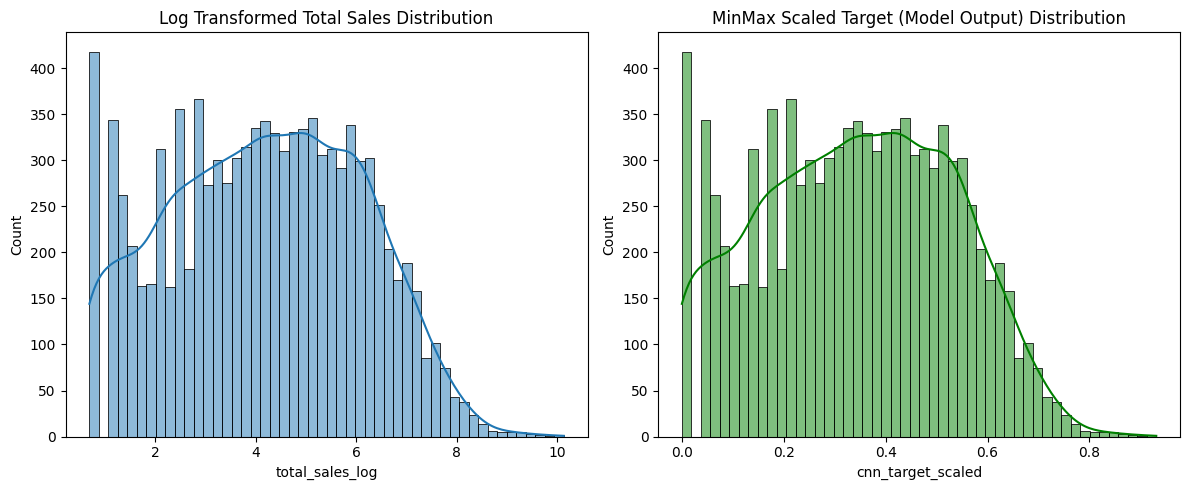

In [23]:
# Visualizing Target Variable to Ensure already applied log-transform + MinMax Scale is healthy:

plt.figure(figsize= (12,5))

plt.subplot(1,2,1)
sns.histplot(df['total_sales_log'], bins= 50, kde= True)
plt.title('Log Transformed Total Sales Distribution')

plt.subplot(1,2,2)
sns.histplot(df['cnn_target_scaled'], bins= 50, kde= True, color= 'green')
plt.title('MinMax Scaled Target (Model Output) Distribution')

plt.tight_layout()
plt.show()

## Train Test Split

In [27]:
train_df, test_df= train_test_split(df, test_size= 0.2, random_state= 42)
print(f"Train DataFrame Shape: {train_df.shape}")
print(f"Test DataFrame Shape: {test_df.shape}")

Train DataFrame Shape: (7968, 6)
Test DataFrame Shape: (1993, 6)


## Data Pipleline with Data Augmentation

In [28]:
# Variables:
BATCH_SIZE= 32
IMG_SIZE= (224, 224)

In [29]:
# Data Augmentation Layer:
data_augmetnation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

I0000 00:00:1782794476.933468    8610 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [30]:
# Processing Images:
def process_image(file_path, label):

    # Read the image from the file path
    image = tf.io.read_file(file_path)
    # Decode the image to a tensor
    image = tf.image.decode_jpeg(image, channels= 3)
    # Resize the image to the desired size
    image = tf.image.resize(image, IMG_SIZE)
    # Normalize the pixel values to [-1, 1] as per MobileNetV2 requirements
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

In [33]:
# Building TensorFlow Dataset:
def build_dataset(dataframe, is_training= True):
    paths= dataframe['file_path'].values
    labels= dataframe['cnn_target_scaled'].values

    ds= tf.data.Dataset.from_tensor_slices((paths, labels))
    ds= ds.map(process_image, num_parallel_calls= tf.data.AUTOTUNE)

    if is_training:

        # Shuffling and Augmenting Data only while Training:
        ds= ds.shuffle(buffer_size= len(dataframe))
        ds= ds.map(lambda x, y: (data_augmetnation(x, training= True), y), 
                   num_parallel_calls= tf.data.AUTOTUNE)
    
    ds= ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

In [34]:
# Training and Validation Datasets:
train_ds= build_dataset(train_df, is_training= True)
val_ds= build_dataset(test_df, is_training= False)